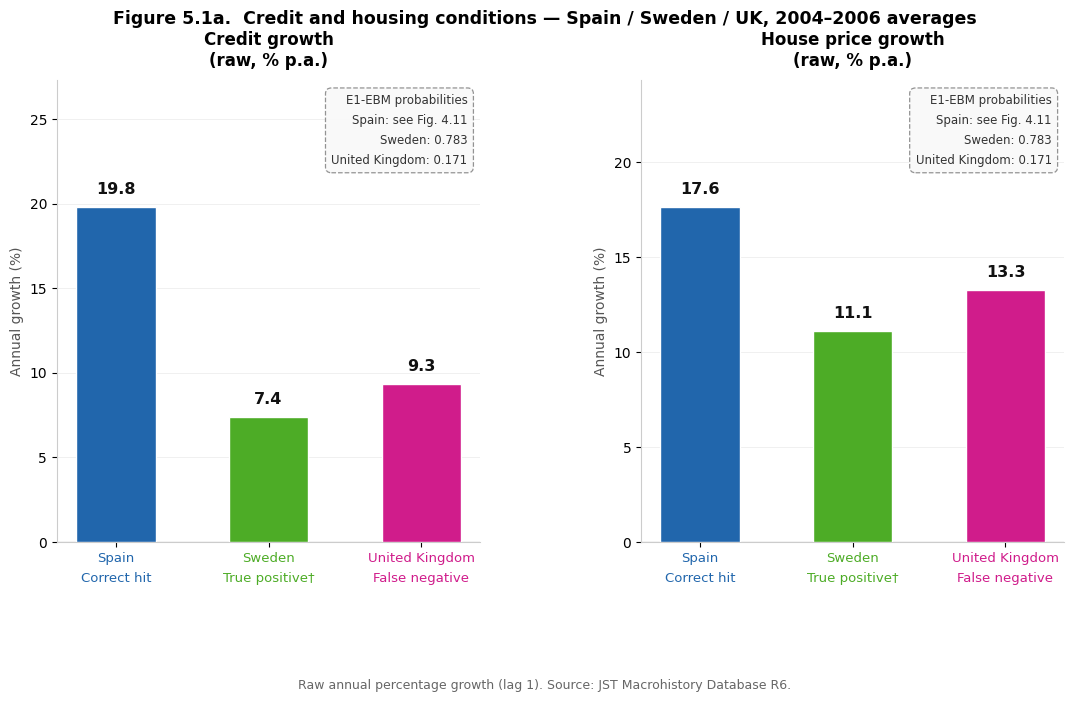

Saved → figures\figure_5_1a_credit_housing.png


In [1]:
# ═══════════════════════════════════════════════════════
# FIGURE 5.1a  Credit & Housing  |  Section 5.4.1
# ═══════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

DATA = (r"C:\Users\Owner\OneDrive\dissertation"
        r"\data\processed\augmented_analysis\df_macro_augmented.csv")
df   = pd.read_csv(DATA)
sub  = df[df['iso'].isin(['ESP','SWE','GBR']) & df['year'].isin([2004,2005,2006])]

ISOS   = ['ESP',         'SWE',             'GBR']
NAMES  = ['Spain',       'Sweden',          'United Kingdom']
ROLES  = ['Correct hit', 'True positive†',  'False negative']
COLORS = ['#2166ac',     '#4dac26',         '#d01c8b']
PROBS  = ['see Fig. 4.11', '0.783',         '0.171']
X, W   = np.arange(3), 0.52

vals = {c: {
    'credit_raw': sub[sub['iso']==c]['tloans_gr_lag1'].mean() * 100,
    'hp_raw':     sub[sub['iso']==c]['hpnom_gr_lag1'].mean() * 100,
} for c in ISOS}

def bar_panel(ax, key, title, ylabel, fmt='.1f'):
    data = [vals[c][key] for c in ISOS]
    bars = ax.bar(X, data, width=W, color=COLORS,
                  edgecolor='white', linewidth=1.0, zorder=3)

    ax.axhline(0, color='#555555', linewidth=0.8, zorder=2)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10, color='#555555')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#cccccc')
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0, max(data) * 1.38)   # headroom for value labels + box

    # ── x-axis: Name + Role, coloured ───────────────────────────
    ax.set_xticks(X)
    ax.set_xticklabels(
        [f'{n}\n{r}' for n, r in zip(NAMES, ROLES)],
        fontsize=9.5, linespacing=1.7
    )
    for tick, col in zip(ax.get_xticklabels(), COLORS):
        tick.set_color(col)

    # ── value label above each bar ───────────────────────────────
    vr = max(abs(v) for v in data) or 1
    for bar, v in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + 0.03 * vr,
                f'{v:{fmt}}',
                ha='center', va='bottom',
                fontsize=11.5, fontweight='bold', color='#111111')

    # ── probability box — top-right, inside axes, dashed border ──
    box_lines = ['E1-EBM probabilities']
    for name, prob, col in zip(NAMES, PROBS, COLORS):
        box_lines.append(f'{name}: {prob}')
    box_text = '\n'.join(box_lines)

    ax.text(
        0.97, 0.97,          # axes-fraction coords: top-right
        box_text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=8.5,
        color='#333333',
        linespacing=1.7,
        bbox=dict(
            boxstyle='round,pad=0.5',
            facecolor='#f9f9f9',
            edgecolor='#888888',
            linestyle='dashed',
            linewidth=0.9,
            alpha=0.9
        )
    )

os.makedirs('figures', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7))
fig.patch.set_facecolor('white')
fig.subplots_adjust(wspace=0.38, bottom=0.22, top=0.88)

bar_panel(ax1, 'credit_raw', 'Credit growth\n(raw, % p.a.)',      'Annual growth (%)')
bar_panel(ax2, 'hp_raw',     'House price growth\n(raw, % p.a.)', 'Annual growth (%)')

fig.suptitle(
    'Figure 5.1a.  Credit and housing conditions — Spain / Sweden / UK, 2004–2006 averages',
    fontsize=12.5, fontweight='bold', y=0.98
)
fig.text(
    0.5, 0.01,
    'Raw annual percentage growth (lag 1). Source: JST Macrohistory Database R6.',
    ha='center', fontsize=9, color='#666666'
)

OUT = r"figures\figure_5_1a_credit_housing.png"
fig.savefig(OUT, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved → {OUT}")

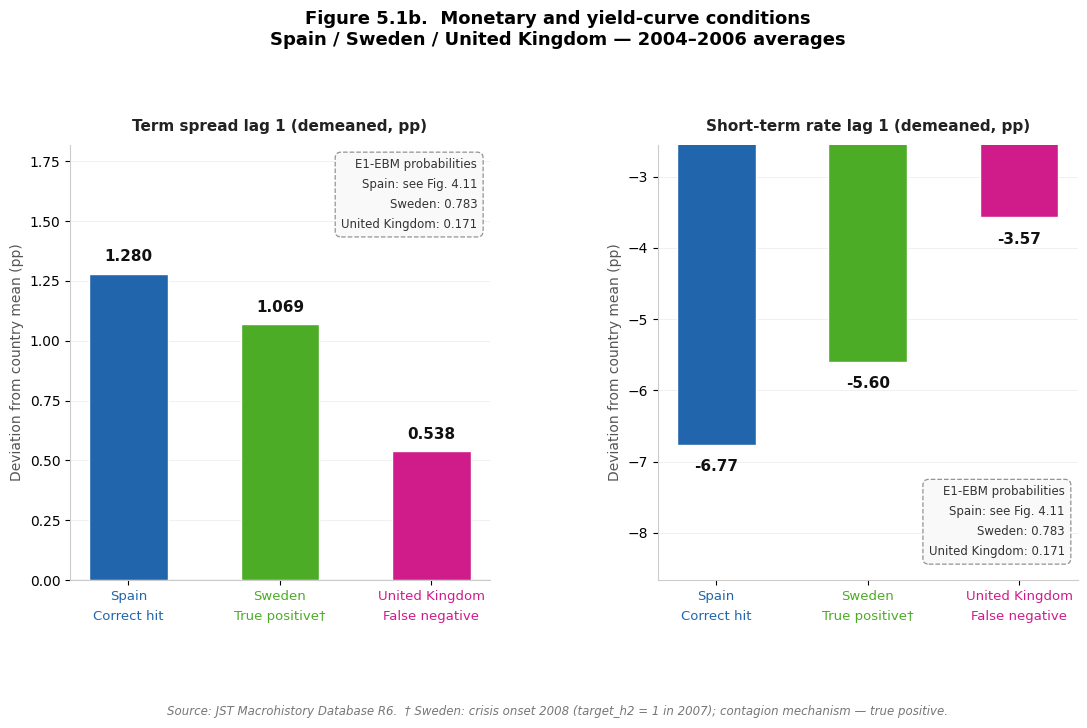

Saved → figures\figure_5_1b_monetary_yield.png


In [3]:
# ═══════════════════════════════════════════════════════
# FIGURE 5.1b  Monetary & Yield-curve  |  Section 5.4.1
# ═══════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

DATA = (r"C:\Users\Owner\OneDrive\dissertation"
        r"\data\processed\augmented_analysis\df_macro_augmented.csv")
df   = pd.read_csv(DATA)
sub  = df[df['iso'].isin(['ESP','SWE','GBR']) & df['year'].isin([2004,2005,2006])]

ISOS   = ['ESP',         'SWE',             'GBR']
NAMES  = ['Spain',       'Sweden',          'United Kingdom']
ROLES  = ['Correct hit', 'True positive†',  'False negative']
COLORS = ['#2166ac',     '#4dac26',         '#d01c8b']
PROBS  = ['see Fig. 4.11', '0.783',         '0.171']
X, W   = np.arange(3), 0.52

vals = {c: {
    'ts_dm':   sub[sub['iso']==c]['term_spread_lag1_dm'].mean(),
    'stir_dm': sub[sub['iso']==c]['stir_lag1_dm'].mean(),
} for c in ISOS}

def bar_panel(ax, key, title, ylabel, fmt='.3f',
              box_x=0.97, box_y=0.97, box_va='top'):
    data = [vals[c][key] for c in ISOS]
    bars = ax.bar(X, data, width=W, color=COLORS,
                  edgecolor='white', linewidth=1.0, zorder=3)

    ax.axhline(0, color='#555555', linewidth=0.8, zorder=2)
    ax.set_title(title, fontsize=11, fontweight='bold',
                 pad=10, color='#222222', loc='center')
    ax.set_ylabel(ylabel, fontsize=10, color='#555555')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#cccccc')
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

    vr      = max(abs(v) for v in data) or 1
    all_neg = all(v <= 0 for v in data)
    all_pos = all(v >= 0 for v in data)

    if all_pos:
        ax.set_ylim(0, max(data) * 1.42)
    elif all_neg:
        ax.set_ylim(min(data) * 1.28, max(data) + vr * 0.15)
    else:
        ax.set_ylim(min(data) * 1.38, max(data) * 1.38)

    # x-axis: Name + Role coloured
    ax.set_xticks(X)
    ax.set_xticklabels(
        [f'{n}\n{r}' for n, r in zip(NAMES, ROLES)],
        fontsize=9.5, linespacing=1.7
    )
    for tick, col in zip(ax.get_xticklabels(), COLORS):
        tick.set_color(col)

    # value label above/below bar
    for bar, v in zip(bars, data):
        offset = 0.03 * vr if v >= 0 else -0.03 * vr
        va     = 'bottom'  if v >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + offset,
                f'{v:{fmt}}',
                ha='center', va=va,
                fontsize=11, fontweight='bold', color='#111111')

    # probability box — position passed per panel
    box_lines = ['E1-EBM probabilities']
    for name, prob in zip(NAMES, PROBS):
        box_lines.append(f'{name}: {prob}')

    ax.text(
        box_x, box_y,
        '\n'.join(box_lines),
        transform=ax.transAxes,
        ha='right', va=box_va,
        fontsize=8.5, color='#333333', linespacing=1.7,
        bbox=dict(
            boxstyle='round,pad=0.5',
            facecolor='#f9f9f9',
            edgecolor='#888888',
            linestyle='dashed',
            linewidth=0.9,
            alpha=0.9
        )
    )

os.makedirs('figures', exist_ok=True)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(13, 7.5))
fig.patch.set_facecolor('white')
fig.subplots_adjust(wspace=0.40, bottom=0.20, top=0.78)

# Term spread — all positive → box top-right (default)
bar_panel(ax3, 'ts_dm',
          'Term spread lag 1 (demeaned, pp)',
          'Deviation from country mean (pp)',
          fmt='.3f',
          box_x=0.97, box_y=0.97, box_va='top')

# Short-term rate — all negative → box bottom-right (clear space)
bar_panel(ax4, 'stir_dm',
          'Short-term rate lag 1 (demeaned, pp)',
          'Deviation from country mean (pp)',
          fmt='.2f',
          box_x=0.97, box_y=0.05, box_va='bottom')

fig.suptitle(
    'Figure 5.1b.  Monetary and yield-curve conditions\n'
    'Spain / Sweden / United Kingdom — 2004–2006 averages',
    fontsize=13, fontweight='bold', y=0.96
)
fig.text(
    0.5, 0.02,
    'Source: JST Macrohistory Database R6.  '
    '† Sweden: crisis onset 2008 (target_h2 = 1 in 2007); '
    'contagion mechanism — true positive.',
    ha='center', fontsize=8.5, color='#777777', style='italic'
)

OUT = r"figures\figure_5_1b_monetary_yield.png"
fig.savefig(OUT, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved → {OUT}")

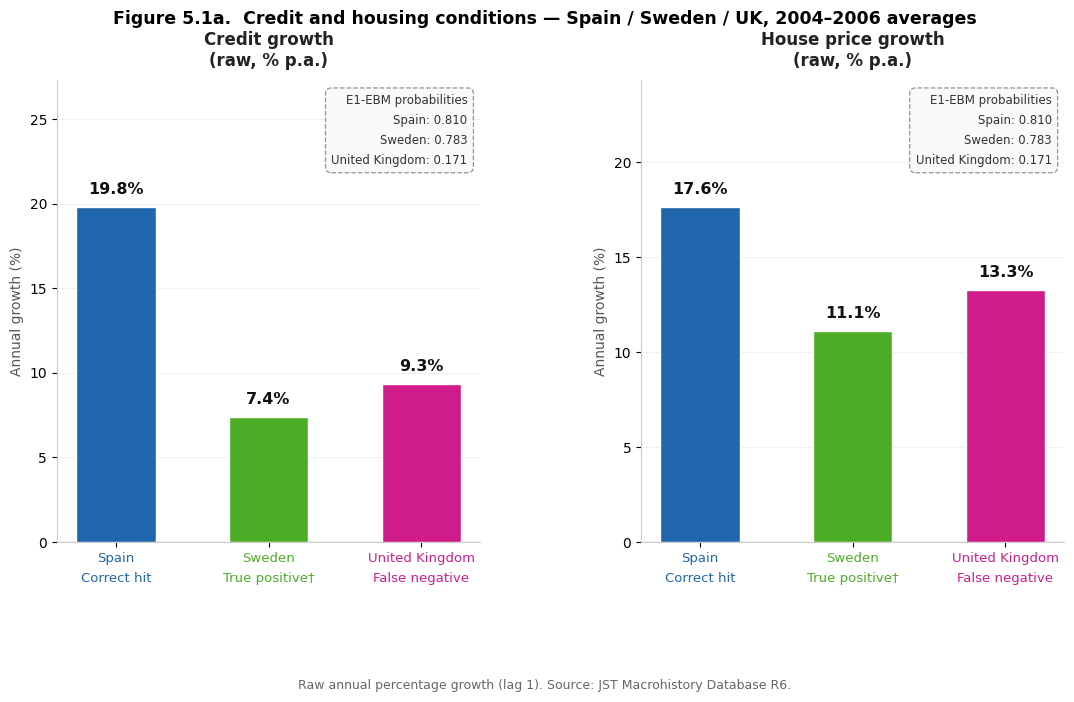

Saved → C:\Users\Owner\OneDrive\dissertation\figures\figure_5_1a_credit_housing.png


In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

DATA = r"C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\df_macro_augmented.csv"
OUT  = r"C:\Users\Owner\OneDrive\dissertation\figures\figure_5_1a_credit_housing.png"

df  = pd.read_csv(DATA)
sub = df[df['iso'].isin(['ESP','SWE','GBR']) & df['year'].isin([2004,2005,2006])]

ISOS   = ['ESP','SWE','GBR']
NAMES  = ['Spain','Sweden','United Kingdom']
ROLES  = ['Correct hit','True positive†','False negative']
COLORS = ['#2166ac','#4dac26','#d01c8b']
PROBS  = ['0.810','0.783','0.171']
X, W   = np.arange(3), 0.52

vals = {c:{
    'credit_raw': sub[sub['iso']==c]['tloans_gr_lag1'].mean()*100,
    'hp_raw':     sub[sub['iso']==c]['hpnom_gr_lag1'].mean()*100,
} for c in ISOS}

def bar_panel(ax, key, title, ylabel):
    data = [vals[c][key] for c in ISOS]
    bars = ax.bar(X, data, width=W, color=COLORS, edgecolor='white', linewidth=1.0, zorder=3)
    ax.axhline(0, color='#555555', linewidth=0.8, zorder=2)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10, color='#222222')
    ax.set_ylabel(ylabel, fontsize=10, color='#555555')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#cccccc')
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0, max(data) * 1.38)
    ax.set_xticks(X)
    ax.set_xticklabels([f'{n}\n{r}' for n,r in zip(NAMES,ROLES)], fontsize=9.5, linespacing=1.7)
    for tick, col in zip(ax.get_xticklabels(), COLORS):
        tick.set_color(col)
    vr = max(abs(v) for v in data) or 1
    for bar, v in zip(bars, data):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.03*vr,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=11.5, fontweight='bold', color='#111111')
    box_lines = ['E1-EBM probabilities'] + [f'{n}: {p}' for n,p in zip(NAMES,PROBS)]
    ax.text(0.97, 0.97, '\n'.join(box_lines), transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, color='#333333', linespacing=1.7,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f9f9',
                      edgecolor='#888888', linestyle='dashed', linewidth=0.9, alpha=0.9))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7))
fig.patch.set_facecolor('white')
fig.subplots_adjust(wspace=0.38, bottom=0.22, top=0.88)
bar_panel(ax1, 'credit_raw', 'Credit growth\n(raw, % p.a.)',      'Annual growth (%)')
bar_panel(ax2, 'hp_raw',     'House price growth\n(raw, % p.a.)', 'Annual growth (%)')
fig.suptitle('Figure 5.1a.  Credit and housing conditions — Spain / Sweden / UK, 2004–2006 averages',
             fontsize=12.5, fontweight='bold', y=0.98)
fig.text(0.5, 0.01, 'Raw annual percentage growth (lag 1). Source: JST Macrohistory Database R6.',
         ha='center', fontsize=9, color='#666666')

os.makedirs(os.path.dirname(OUT), exist_ok=True)
fig.savefig(OUT, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved → {OUT}")

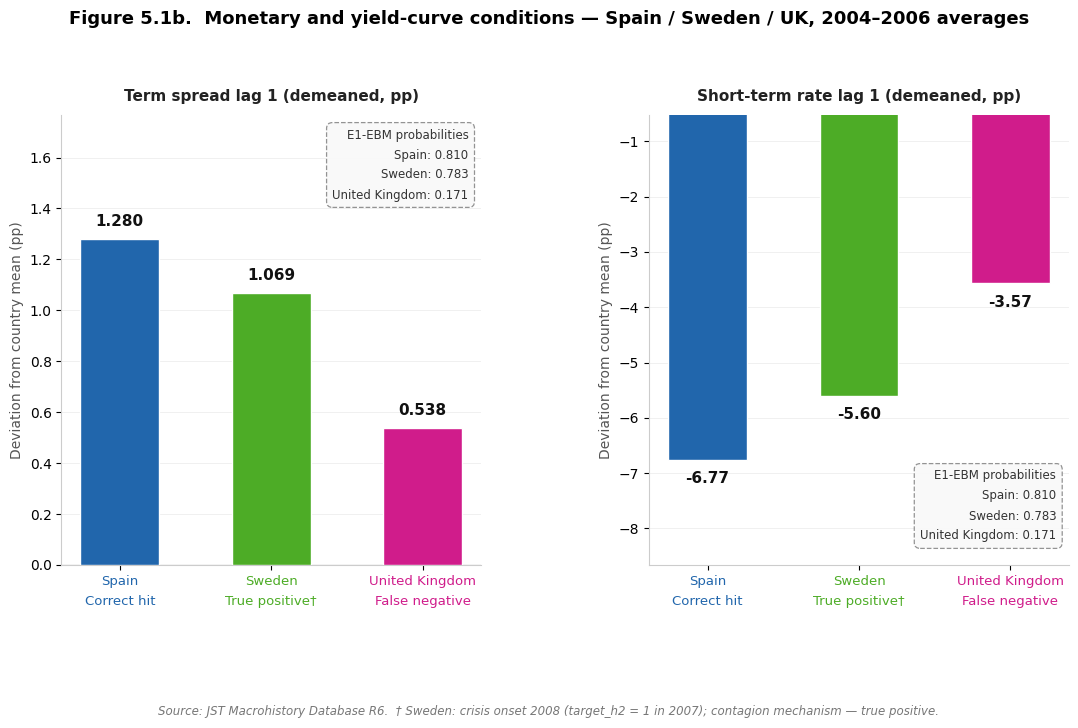

Saved → C:\Users\Owner\OneDrive\dissertation\figures\figure_5_1b_monetary_yield.png


In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

DATA = r"C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\df_macro_augmented.csv"
OUT  = r"C:\Users\Owner\OneDrive\dissertation\figures\figure_5_1b_monetary_yield.png"

df  = pd.read_csv(DATA)
sub = df[df['iso'].isin(['ESP','SWE','GBR']) & df['year'].isin([2004,2005,2006])]

ISOS   = ['ESP','SWE','GBR']
NAMES  = ['Spain','Sweden','United Kingdom']
ROLES  = ['Correct hit','True positive†','False negative']
COLORS = ['#2166ac','#4dac26','#d01c8b']
PROBS  = ['0.810','0.783','0.171']
X, W   = np.arange(3), 0.52

vals = {c:{
    'ts_dm':   sub[sub['iso']==c]['term_spread_lag1_dm'].mean(),
    'stir_dm': sub[sub['iso']==c]['stir_lag1_dm'].mean(),
} for c in ISOS}

def bar_panel(ax, key, title, ylabel, fmt='.3f', box_x=0.97, box_y=0.97, box_va='top'):
    data = [vals[c][key] for c in ISOS]
    bars = ax.bar(X, data, width=W, color=COLORS, edgecolor='white', linewidth=1.0, zorder=3)
    ax.axhline(0, color='#555555', linewidth=0.8, zorder=2)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, color='#222222')
    ax.set_ylabel(ylabel, fontsize=10, color='#555555')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#cccccc')
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    vr      = max(abs(v) for v in data) or 1
    all_neg = all(v <= 0 for v in data)
    all_pos = all(v >= 0 for v in data)
    if all_pos:   ax.set_ylim(0, max(data)*1.38)
    elif all_neg: ax.set_ylim(min(data)*1.28, max(data)+vr*0.45)
    else:         ax.set_ylim(min(data)*1.38, max(data)*1.38)
    ax.set_xticks(X)
    ax.set_xticklabels([f'{n}\n{r}' for n,r in zip(NAMES,ROLES)], fontsize=9.5, linespacing=1.7)
    for tick, col in zip(ax.get_xticklabels(), COLORS):
        tick.set_color(col)
    for bar, v in zip(bars, data):
        offset = 0.03*vr if v >= 0 else -0.03*vr
        ax.text(bar.get_x()+bar.get_width()/2, v+offset, f'{v:{fmt}}',
                ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=11, fontweight='bold', color='#111111')
    box_lines = ['E1-EBM probabilities'] + [f'{n}: {p}' for n,p in zip(NAMES,PROBS)]
    ax.text(box_x, box_y, '\n'.join(box_lines), transform=ax.transAxes,
            ha='right', va=box_va, fontsize=8.5, color='#333333', linespacing=1.7,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f9f9',
                      edgecolor='#888888', linestyle='dashed', linewidth=0.9, alpha=0.9))

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(13, 7.5))
fig.patch.set_facecolor('white')
fig.subplots_adjust(wspace=0.40, bottom=0.22, top=0.82)
bar_panel(ax3, 'ts_dm',   'Term spread lag 1 (demeaned, pp)',
          'Deviation from country mean (pp)', fmt='.3f', box_x=0.97, box_y=0.97, box_va='top')
bar_panel(ax4, 'stir_dm', 'Short-term rate lag 1 (demeaned, pp)',
          'Deviation from country mean (pp)', fmt='.2f', box_x=0.97, box_y=0.05, box_va='bottom')
fig.suptitle('Figure 5.1b.  Monetary and yield-curve conditions — Spain / Sweden / UK, 2004–2006 averages',
             fontsize=13, fontweight='bold', y=0.96)
fig.text(0.5, 0.02,
         'Source: JST Macrohistory Database R6.  '
         '† Sweden: crisis onset 2008 (target_h2 = 1 in 2007); contagion mechanism — true positive.',
         ha='center', fontsize=8.5, color='#777777', style='italic')

os.makedirs(os.path.dirname(OUT), exist_ok=True)
fig.savefig(OUT, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved → {OUT}")

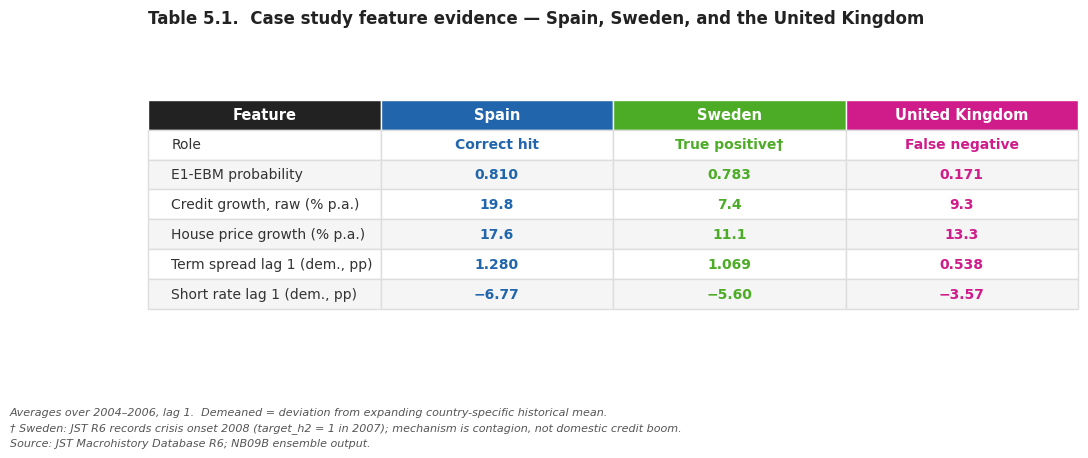

Saved → C:\Users\Owner\OneDrive\dissertation\figures\table_5_1_case_study_summary.png


In [9]:
import matplotlib.pyplot as plt, os

OUT    = r"C:\Users\Owner\OneDrive\dissertation\figures\table_5_1_case_study_summary.png"
COLORS = ['#2166ac','#4dac26','#d01c8b']

col_headers = ['Feature','Spain','Sweden','United Kingdom']
rows = [
    ['Role',                         'Correct hit',   'True positive†', 'False negative'],
    ['E1-EBM probability',           '0.810',         '0.783',          '0.171'],
    ['Credit growth, raw (% p.a.)',  '19.8',          '7.4',            '9.3'],
    ['House price growth (% p.a.)',  '17.6',          '11.1',           '13.3'],
    ['Term spread lag 1 (dem., pp)', '1.280',         '1.069',          '0.538'],
    ['Short rate lag 1 (dem., pp)',  '−6.77',         '−5.60',          '−3.57'],
]
note = ('Averages over 2004–2006, lag 1.  Demeaned = deviation from expanding country-specific historical mean.\n'
        '† Sweden: JST R6 records crisis onset 2008 (target_h2 = 1 in 2007); mechanism is contagion, not domestic credit boom.\n'
        'Source: JST Macrohistory Database R6; NB09B ensemble output.')

fig, ax = plt.subplots(figsize=(12, 4.2))
fig.patch.set_facecolor('white')
ax.axis('off')

tbl = ax.table(cellText=rows, colLabels=col_headers, cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)

for col_idx, color in enumerate(['#333333']+COLORS):
    cell = tbl[0, col_idx]
    cell.set_facecolor('#222222' if col_idx == 0 else color)
    cell.set_text_props(color='white', fontweight='bold', fontsize=10.5)
    cell.set_edgecolor('white')

for row_idx in range(1, len(rows)+1):
    bg = '#f5f5f5' if row_idx % 2 == 0 else 'white'
    for col_idx in range(4):
        cell = tbl[row_idx, col_idx]
        cell.set_facecolor(bg)
        cell.set_edgecolor('#dddddd')
        if col_idx > 0:
            cell.set_text_props(color=COLORS[col_idx-1], fontweight='bold')
        if col_idx == 0:
            cell.set_text_props(color='#333333', fontweight='normal', ha='left')

ax.set_title('Table 5.1.  Case study feature evidence — Spain, Sweden, and the United Kingdom',
             fontsize=12, fontweight='bold', pad=14, loc='left', color='#222222')
fig.text(0.01, -0.08, note, fontsize=8, color='#555555', style='italic', linespacing=1.6)

os.makedirs(os.path.dirname(OUT), exist_ok=True)
fig.savefig(OUT, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved → {OUT}")